# Housing price prediction analysis
This project uses the King County Housing Prices dataset, which contains information about residential home sales in King County, Washington, USA. The dataset includes various features describing the properties such as size, number of rooms, condition, and location. The goal of this project is to analyze how these housing characteristics relate to sale price and to build regression models that can predict housing prices.

Dataset source:
https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

The dataset contains 21 variables describing housing characteristics and the sale price of each property.

### Explanation of Key Columns
price – Sale price of the house (target variable).
bedrooms – Number of bedrooms.
bathrooms – Number of bathrooms.
sqft_living – Living area square footage.
sqft_lot – Lot size in square feet.
floors – Number of floors in the house.
grade – Overall construction and design quality.
condition – Condition rating of the house.
yr_built – Year the house was built.
zipcode – Location of the property.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("data.csv")

## Understanding the dataset

In [16]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [17]:
df.shape

(21613, 21)

The dataset contains approximately 21000 housing price observations

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

This shows that there are 21 variables describing housing sales in King County. Most are numerical, integers or floats representing house characteristics.

In [19]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


This shows the statistical summary of the dataset.

## missing value check

In [20]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

The results show that there are no missing values meaning the dataset is complete

## Duplicate check

In [26]:
df.duplicated().sum()

np.int64(0)

There were no dupicates showing there is no repeated observation

## First Visualization

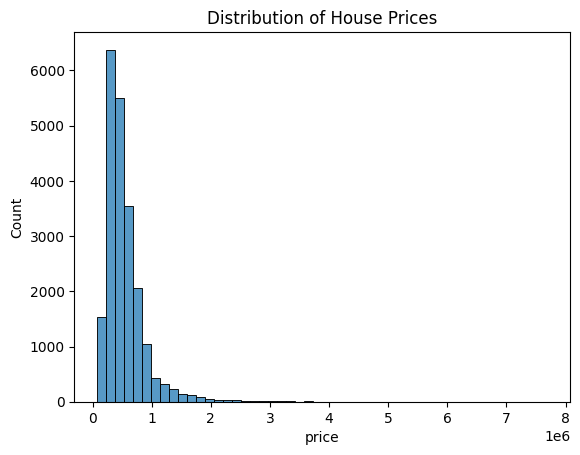

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price"], bins=50)
plt.title("Distribution of House Prices")
plt.show()

The distribution of housing prices is right-skewed, meaning most houses are moderately priced while a smaller number of houses have very high prices.

## Scatter plot showing the relationship between variables

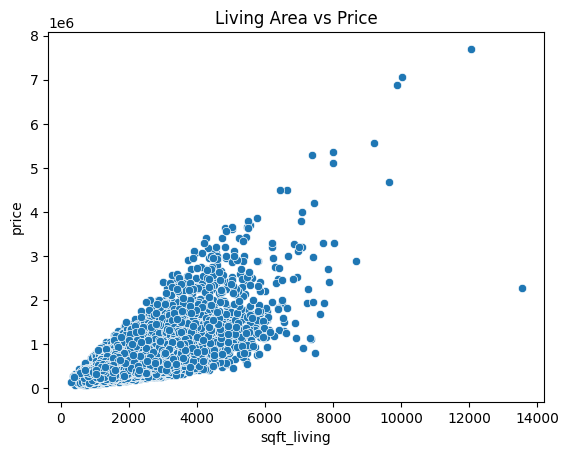

In [29]:
sns.scatterplot(x=df["sqft_living"], y=df["price"])
plt.title("Living Area vs Price")
plt.show()

This shows houses with larger living areas tend to be more expensive

## Correlation heatmap showing which variables relate most to price

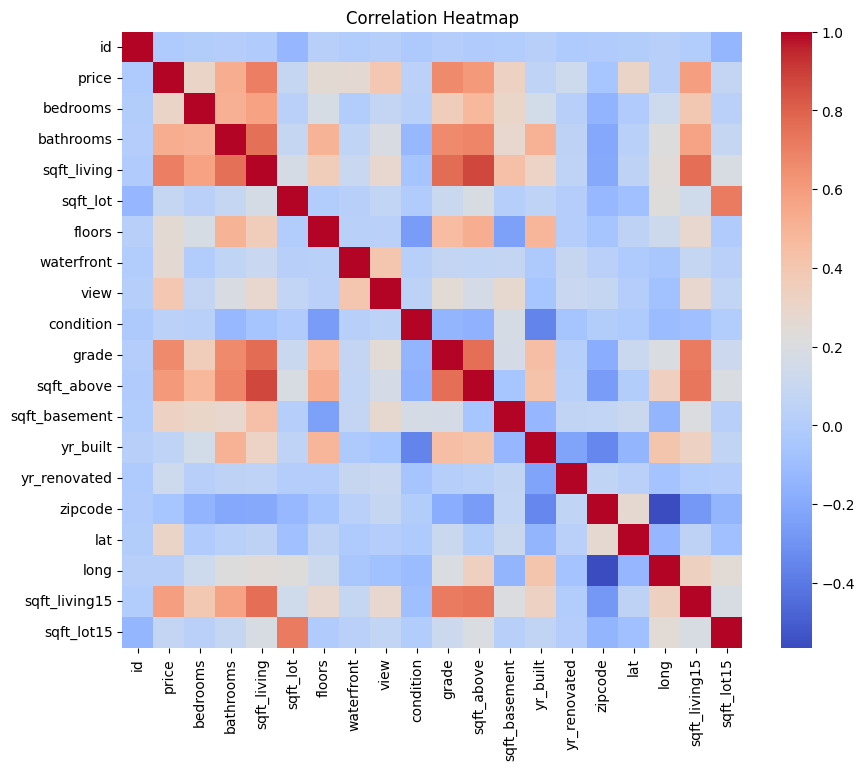

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows the relationships between the numerical variables in the dataset.  
From the heatmap, variables such as sqft_living, grade, and bathrooms appear to have strong positive correlations with house prices. This suggests that larger homes with higher construction quality tend to have higher sale prices.

### EDA Summary

The exploratory data analysis showed that house prices are right-skewed, with some high-value outliers. 
The scatter plot between living area and price showed a strong positive relationship, indicating that larger homes tend to have higher prices.

The correlation heatmap also revealed that variables such as **sqft_living**, **grade**, and **bathrooms** have relatively strong correlations with house prices. These variables may therefore be useful predictors in regression models.

## Modeling

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[['sqft_living']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [35]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 276559.1746114674
MAE: 177867.54034434847
R²: 0.49406905389089006


### Linear Regression Results
The linear regression model was used to predict housing prices based on the living area of the home (sqft_living).  

The model produced an RMSE of approximately 276,559 and an MAE of about 177,868, showing that the average prediction error is fairly large when predicting prices using only one variable.

The R² value is approximately 0.49, meaning that about 49% of the variation in housing prices can be explained by the living area alone. This suggests that while living area is an important factor,other variables will likely improve the model's predictive performance.

## Polynomial Regression

In [37]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [38]:
model_poly = LinearRegression()

model_poly.fit(X_poly_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred_poly = model_poly.predict(X_poly_test)

In [40]:
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R²:", r2_poly)

Polynomial Regression Results
RMSE: 286555.2846897853
MAE: 171786.30972476825
R²: 0.45683478653690834


The polynomial regression model produced an RMSE of 286,555.28, MAE of 171,786.31, and R² of 0.4568. Compared with the linear regression model, polynomial regression did not improve performance. This suggests the model did not capture additional meaningful structure in the data and may have slightly reduced generalization.

### Ridge Regression

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1))
])

In [47]:
ridge_pipeline.fit(X_train, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)

In [48]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R²:", r2_ridge)

Ridge Regression Results
RMSE: 276559.43966335524
MAE: 177865.11617946002
R²: 0.4940680841308607


Ridge regression produced results identical to the linear regression model, with an RMSE of approximately 276,559 and an R² of 0.494. This suggests that the regularization parameter (α = 1) was not strong enough to significantly shrink the model coefficients. As a result, the Ridge model behaved similarly to ordinary least squares regression.

### Hyperparameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best alpha: {'alpha': 1000}
Best cross-validation score: 0.4909420921973463


In [51]:
best_ridge = grid_search.best_estimator_

y_pred_best = best_ridge.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Tuned Ridge Regression Results")
print("RMSE:", rmse_best)
print("MAE:", mae_best)
print("R²:", r2_best)

Tuned Ridge Regression Results
RMSE: 276559.1749329559
MAE: 177867.5373991642
R²: 0.49406905271464296


To determine the optimal regularization strength, GridSearchCV was used to test multiple alpha values for the Ridge regression model. The grid search evaluated α values ranging from 0.01 to 1000 using 5-fold cross-validation. The best alpha value was found to be 1000, which produced an RMSE of 276559.1749329559 and an R² of 0.49406905271464296 on the test dataset.

### Comparing Models

In [58]:
#Linear Regression Results 
RMSE: 276559.1746114674
MAE: 177867.54034434847
R2: 0.49406905389089006

In [59]:
#Polynomial Regression Results
RMSE: 286555.2846897853
MAE: 171786.30972476825
R2: 0.45683478653690834

In [60]:
#Ridge Regression Results
RMSE: 276559.43966335524
MAE: 177865.11617946002
R2: 0.4940680841308607

Linear regression and ridge regression produced similar results, with an R² of approximately 0.49. Polynomial regression performed slightly worse, indicating that increasing model complexity did not improve predictive performance.

### Conclusion

This project analyzed housing prices in King County using regression models to understand how different housing characteristics influence price. Exploratory data analysis revealed strong relationships between variables such as square footage, number of bathrooms, and property grade with housing price. Three models were implemented to predict housing prices: linear regression, polynomial regression, and ridge regression.
The results showed that linear regression and ridge regression produced very similar performance metrics, with an R² value of approximately 0.49. Polynomial regression performed slightly worse, suggesting that increasing model complexity did not significantly improve predictive performance. Ridge regression was further optimized using hyperparameter tuning to determine the best alpha value, though regularization did not substantially improve the model’s accuracy.
Overall, the analysis suggests that the relationship between housing features and price is largely linear in this dataset. While the models provide useful predictions, the relatively moderate R² score indicates that additional variables or more advanced modeling techniques may be required to improve predictive accuracy.